In [1]:
import torch
import torch.nn as nn
import numpy as np
import time
from scipy.stats import qmc
from collections import OrderedDict
import matplotlib.pyplot as plt
from datetime import datetime 
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
# Checar se a gpu sera usada para acelerar o processamento
is_cuda_available = torch.cuda.is_available()
print("Is CUDA (GPU support) available in PyTorch:", is_cuda_available)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
# Define o dispositivo (GPU ou CPU)
torch.manual_seed(23)
np.random.seed(23)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# ==============================================================================
# Parte 1: Parâmetros, Domínio e Arquitetura da Rede
# ==============================================================================

# Parâmetros do sistema
params = {
    'b': 30.0,
    'a': 10.0,
    'delta': [3000.0, 100.0, 300.0, 100.0, 30.0],
    'kappa': 0.1,
    'epsilon_0': 1.0,
    'epsilon_r': 80.0,
    'kbT': 1.0,
    'r_max': 100.0
}

class CircularDomain:
    """
    Classe para gerar e gerenciar os pontos de amostragem
    para o domínio em formato de "donut" (anular).
    """
    def __init__(self, r_in, r_out, n_boundary_points, n_colloc_points, n_periodic_points, bc1_val, bc2_val):
        self.r_in, self.r_out = r_in, r_out
        self.n_bcp = n_boundary_points
        self.n_cp = n_colloc_points
        # n_periodic_points não é mais usado, mas mantido para compatibilidade de chamada
        self.n_pp = n_periodic_points
        self.bc1_val = bc1_val
        self.bc2_val = bc2_val
        self.colloc = None
        self.data = None
        self.bc_values = None

    def __circle(self, radius, n):
        t = np.linspace(0, 2 * np.pi, n, endpoint=False)
        x = radius * np.cos(t)
        y = radius * np.sin(t)
        return x, y

    def __is_doughnut(self, x, y, r_out, r_in=0):
        r_sq = x**2 + y**2
        return (r_in**2 <= r_sq) & (r_sq < r_out**2)
    
    def makeDomain(self):
        """Gera os pontos de colocation e de contorno (BC)."""
        # 1. Pontos de Colocation (Interior do "donut")
        # Usando qmc.Halton para amostragem de baixa discrepância
        sampler = qmc.Halton(d=2)
        points = (2 * (sampler.random(self.n_cp) - 0.5)) * self.r_out
        x_colloc, y_colloc = points[:, 0], points[:, 1]
        mask = self.__is_doughnut(x_colloc, y_colloc, self.r_out, self.r_in)
        x_colloc, y_colloc = x_colloc[mask], y_colloc[mask]
        
        # Distribui N (comprimento da cadeia) linearmente entre os pontos
        N_colloc = np.linspace(1, 100, x_colloc.shape[0])

        # 2. Pontos de Contorno (BC)
        x_bc_in, y_bc_in = self.__circle(self.r_in, self.n_bcp)
        N_bc_in = np.linspace(1, 100, x_bc_in.shape[0])
        bc_in_values = np.ones_like(x_bc_in) * self.bc1_val

        x_bc_out, y_bc_out = self.__circle(self.r_out, self.n_bcp)
        N_bc_out = np.linspace(1, 100, x_bc_out.shape[0])
        bc_out_values = np.ones_like(x_bc_out) * self.bc2_val

        # Combinando os pontos de contorno
        x_data = np.concatenate([x_bc_in, x_bc_out])
        y_data = np.concatenate([y_bc_in, y_bc_out])
        N_data = np.concatenate([N_bc_in, N_bc_out])
        bc_values = np.concatenate([bc_in_values, bc_out_values])
        
        # Plotando o domínio para visualização
        plt.figure(figsize=(8, 8))
        plt.plot(x_colloc, y_colloc, '.', markersize=2, label='Collocation Points')
        plt.plot(x_bc_in, y_bc_in, 'r.', markersize=5, label='Inner Boundary')
        plt.plot(x_bc_out, y_bc_out, 'g.', markersize=5, label='Outer Boundary')
        plt.title('Domain and Sampled Points')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.axis('equal')
        plt.legend()
        plt.grid(True)
        plt.show()

        self.colloc = np.vstack([x_colloc, y_colloc, N_colloc]).T
        self.data = np.vstack([x_data, y_data, N_data]).T
        self.bc_values = bc_values.reshape(-1, 1)

class FourierFeatures(nn.Module):
    """Implementação de Random Fourier Features (RFF)."""
    def __init__(self, in_features, out_features, scale=1.0):
        super(FourierFeatures, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.scale = scale
        # A matriz B não é treinável
        self.weight = nn.Parameter(torch.randn(out_features // 2, in_features) * self.scale, requires_grad=False)
    
    def forward(self, x):
        x_proj = x @ self.weight.T
        # [sin(Bx), cos(Bx)]
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class PINN(nn.Module):
    """
    Rede Neural que aproxima a função G(x, y, N).
    """
    def __init__(self):
        super(PINN, self).__init__()
        
        # Hiperparâmetros otimizados (encontrados pelo usuário)
        # Dimensão da RFF (capacidade expressiva)
        fourier_features_dim = 50 
        # Dimensão das camadas internas (capacidade de processamento)
        inner_layer_dim = 100
        # Escala da RFF (frequência)
        self.rff_scale = 0.01 
        
        self.fourier_features = FourierFeatures(in_features=3, out_features=fourier_features_dim, scale=self.rff_scale)

        # Rede MLP
        self.net = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(fourier_features_dim, inner_layer_dim)),
            ('act1', nn.Tanh()),
            ('fc2', nn.Linear(inner_layer_dim, inner_layer_dim)),
            ('act2', nn.Tanh()),
            ('fc3', nn.Linear(inner_layer_dim, inner_layer_dim)),
            ('act3', nn.Tanh()),
            ('fc4', nn.Linear(inner_layer_dim, inner_layer_dim)),
            ('act4', nn.Tanh()),
            ('fc5', nn.Linear(inner_layer_dim, inner_layer_dim)),
            ('act5', nn.Tanh()),
            ('fc6', nn.Linear(inner_layer_dim, inner_layer_dim)),
            ('act6', nn.Tanh()),
            ('fc7', nn.Linear(inner_layer_dim, inner_layer_dim)),
            ('act7', nn.Tanh()),
            ('fc8', nn.Linear(inner_layer_dim, inner_layer_dim)),
            ('act8', nn.Tanh()),
            ('fc9', nn.Linear(inner_layer_dim, inner_layer_dim)),
            ('act9', nn.Tanh()),
            ('fc10', nn.Linear(inner_layer_dim, inner_layer_dim,1))
        ]))

    def forward(self, x):
        x_fourier = self.fourier_features(x)
        return self.net(x_fourier)

In [15]:
# ==============================================================================
# Parte 2: Funções de Perda (Physics + Boundary Conditions)
# ==============================================================================

def get_coords(x, y):
    """Calcula coordenadas polares (r, theta) a partir de (x, y)."""
    r = torch.sqrt(x**2 + y**2)
    theta = torch.atan2(y, x) # atan2 lida corretamente com todos os quadrantes
    return r, theta

def get_potential(r, theta, params):
    """Calcula o potencial V(r, theta) com a dependência em cos(theta)."""
    delta = params['delta']
    kappa = params['kappa']
    a = params['a']
    
    # Termo radial (Debye-Huckel)
    V_r = (-delta * params['b'] * torch.exp(-kappa * (r - a))) / (6 * a * (1 + kappa * a) * r)
    
    # Termo angular (Assimetria)
    V_theta = torch.cos(theta)
    
    return V_r * V_theta

def pde_loss(model, x_interior, y_interior, N_interior, params):
    """Calcula o resíduo da Equação de Edwards (Loss da PDE)."""
    
    # Ativa a necessidade de gradientes para as entradas (necessário para o Laplaciano)
    x_interior.requires_grad = True
    y_interior.requires_grad = True
    N_interior.requires_grad = True

    # Passa as coordenadas (x, y, N) para o modelo
    G = model(torch.cat([x_interior, y_interior, N_interior], dim=1))
    
    # --- Cálculo do Laplaciano via Autograd ---
    # Primeira derivada (G_x, G_y)
    G_grads = torch.autograd.grad(G, [x_interior, y_interior], 
                                  grad_outputs=torch.ones_like(G), 
                                  create_graph=True, 
                                  retain_graph=True)
    G_x = G_grads[0]
    G_y = G_grads[1]
    
    # Segunda derivada (G_xx, G_yy)
    G_xx = torch.autograd.grad(G_x, x_interior, 
                               grad_outputs=torch.ones_like(G_x), 
                               create_graph=True, 
                               retain_graph=True)[0]
    G_yy = torch.autograd.grad(G_y, y_interior, 
                               grad_outputs=torch.ones_like(G_y), 
                               create_graph=True, 
                               retain_graph=True)[0]
    
    laplacian_G = G_xx + G_yy
    
    # --- Cálculo da Derivada em N ---
    dG_dN = torch.autograd.grad(G, N_interior, 
                                grad_outputs=torch.ones_like(G), 
                                create_graph=True, 
                                retain_graph=True)[0]
    
    # --- Cálculo do Potencial ---
    r_interior, theta_interior = get_coords(x_interior, y_interior)
    V = get_potential(r_interior, theta_interior, params)
    
    # --- Montagem do Resíduo da PDE ---
    # residual = - (b^2/6) * Laplaciano + (V/kbT) * G + dG/dN
    residual = - (params['b']**2 / 6) * laplacian_G + \
                 (V / params['kbT']) * G + \
                 dG_dN
    
    # A perda é o Erro Quadrático Médio do resíduo (queremos residual=0)
    return torch.mean(residual**2)

def bc_loss(model, x_bc, y_bc, N_bc):
    """
    Calcula a perda das Condições de Contorno Radiais (Dirichlet).
    Força G(r=a, N) = 0 e G(r=R, N) = 0.
    """
    G_bc = model(torch.cat([x_bc, y_bc, N_bc], dim=1))
    
    # Força a saída (G) a ser zero nos pontos de contorno
    return torch.mean(G_bc**2)

def normalization_loss(model, x_interior, y_interior, N_interior, domain_area):
    """
    Calcula a perda de Normalização.
    Força a integral de G^2 sobre o domínio ser 1.
    """
    G = model(torch.cat([x_interior, y_interior, N_interior], dim=1))
    
    # Aproxima a integral de G^2 usando a média dos pontos de colocation
    # (Integração de Monte Carlo)
    # Integral(G^2) ~= Area * Média(G^2)
    integral_G_squared = domain_area * torch.mean(G**2)
    
    # Queremos que a integral seja 1
    return torch.mean((integral_G_squared - 1.0)**2)


In [16]:
# ==============================================================================
# Parte 3: Amostragem do Domínio (Classe CircularDomain)
# ==============================================================================

class CircularDomain:
    """
    Gerencia a amostragem de pontos de colocation (interiores)
    e de contorno (fronteiras radiais).
    """
    def __init__(self, r_in, r_out, n_boundary_points, n_colloc_points, bc1_val, bc2_val):
        self.r_in = r_in
        self.r_out = r_out
        self.n_bcp = n_boundary_points # Pontos em cada fronteira
        self.n_cp = n_colloc_points
        self.bc1_val = bc1_val # Valor em r_in (G=0)
        self.bc2_val = bc2_val # Valor em r_out (G=0)
        
        # Inicializa dados
        self.colloc = None
        self.data = None
        self.bc_values = None

    def __circle(self, radius, n):
        """Gera pontos em um círculo."""
        t = np.linspace(0, 2 * np.pi, n, endpoint=False)
        x = radius * np.cos(t)
        y = radius * np.sin(t)
        return x, y

    def __is_doughnut(self, x, y, r_out, r_in=0):
        """Máscara booleana para pontos dentro do anel (rosquinha)."""
        r_squared = x**2 + y**2
        return (r_squared >= r_in**2) & (r_squared <= r_out**2)
    
    def makeDomain(self):
        """Gera todos os pontos de amostragem."""
        
        # 1. Pontos de Colocation (Interiores)
        # Amostragem Halton (Quasi-Monte Carlo) para melhor distribuição
        sampler = qmc.Halton(d=2, scramble=True)
        # Amostra em um quadrado [-r_out, r_out] x [-r_out, r_out]
        points = (sampler.random(self.n_cp) * 2 - 1) * self.r_out
        x_colloc, y_colloc = points[:, 0], points[:, 1]
        
        # Filtra (mascara) apenas os pontos que estão dentro do anel
        mask = self.__is_doughnut(x_colloc, y_colloc, self.r_out, self.r_in)
        x_colloc, y_colloc = x_colloc[mask], y_colloc[mask]
        
        # Amostra N (comprimento do polímero) linearmente
        # Isso é crucial para o modelo aprender dG/dN
        N_colloc = np.linspace(1, 100, x_colloc.shape[0])

        # 2. Pontos de Contorno (Fronteiras Radiais)
        # Fronteira interna (r = r_in)
        x_bc_in, y_bc_in = self.__circle(self.r_in, self.n_bcp)
        N_bc_in = np.linspace(1, 100, x_bc_in.shape[0])
        bc_in_values = np.ones_like(x_bc_in) * self.bc1_val

        # Fronteira externa (r = r_out)
        x_bc_out, y_bc_out = self.__circle(self.r_out, self.n_bcp)
        N_bc_out = np.linspace(1, 100, x_bc_out.shape[0])
        bc_out_values = np.ones_like(x_bc_out) * self.bc2_val

        # 3. Combina os dados de contorno
        x_data = np.concatenate([x_bc_in, x_bc_out])
        y_data = np.concatenate([y_bc_in, y_bc_out])
        N_data = np.concatenate([N_bc_in, N_bc_out])
        bc_values = np.concatenate([bc_in_values, bc_out_values])

        # Plotando o domínio para verificação
        plt.figure(figsize=(8, 8))
        plt.plot(x_colloc, y_colloc, '.', markersize=1, alpha=0.5, label='Collocation Points')
        plt.plot(x_bc_in, y_bc_in, 'r.', markersize=4, label='Inner Boundary (r=a)')
        plt.plot(x_bc_out, y_bc_out, 'g.', markersize=4, label='Outer Boundary (r=R)')
        plt.title('Domain and Sampled Points')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.axis('equal')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Armazena os resultados na classe
        self.colloc = np.vstack([x_colloc, y_colloc, N_colloc]).T
        self.data = np.vstack([x_data, y_data, N_data]).T
        self.bc_values = bc_values.reshape(-1, 1)


In [17]:
# ==============================================================================
# Parte 4: Funções de Visualização e Geração de Vídeo
# ==============================================================================

def convert_to_torch_tensor(arr, device):
    """Converte array NumPy para tensor PyTorch no device correto."""
    if arr is None:
        return None
    return torch.from_numpy(arr).float().to(device)

def predict_density_map(model, x_flat_np, y_flat_np, N_flat_np, device):
    """
    Função auxiliar robusta para predição.
    Usa mini-batching para evitar OOM (CUDA Out of Memory) e
    corrige o shape da saída (problema de (N, 100) vs (N, 1)).
    """
    
    # Tamanho do lote para predição (para evitar OOM)
    # Reduzido para 4096 para garantir estabilidade
    PRED_BATCH_SIZE = 4096 
    
    total_points = x_flat_np.shape[0]
    P_list = []
    
    # Coloca o modelo em modo de avaliação (desliga dropout, etc.)
    model.eval()
    with torch.no_grad(): # Desliga o cálculo de gradientes (essencial para OOM)
        for i in range(0, total_points, PRED_BATCH_SIZE):
            # Move apenas o lote atual para a GPU
            X_batch = convert_to_torch_tensor(x_flat_np[i:i + PRED_BATCH_SIZE], device).unsqueeze(1)
            Y_batch = convert_to_torch_tensor(y_flat_np[i:i + PRED_BATCH_SIZE], device).unsqueeze(1)
            N_batch = convert_to_torch_tensor(N_flat_np[i:i + PRED_BATCH_SIZE], device).unsqueeze(1)
            
            # Concatena o lote
            batch_input = torch.cat([X_batch, Y_batch, N_batch], dim=1)
            
            # Predição
            P_batch_output = model(batch_input)
            
            # --- Correção Crítica do Shape ---
            # O modelo pode retornar (N, 100) ou (N, 1) dependendo do estado do kernel.
            # Força a seleção da primeira coluna se houver muitas.
            if P_batch_output.shape[1] > 1:
                P_batch_output = P_batch_output[:, 0] # Pega a primeira coluna
            # ---------------------------------

            P_list.append(P_batch_output.cpu().numpy())
    
    # Retorna ao modo de treino
    model.train() 

    # Concatena os resultados dos lotes
    P_grid_flat = np.concatenate(P_list).squeeze() # Agora squeeze é seguro
    
    P_grid = None
    # Tenta remodelar para 2D (se a entrada for 2D)
    try:
        grid_dim = int(np.sqrt(total_points))
        if grid_dim * grid_dim == total_points:
             P_grid = P_grid_flat.reshape(grid_dim, grid_dim)
    except ValueError:
        pass # Ignora se não for uma grade quadrada

    # Retorna G (P_grid_flat) e G^2 (P_grid**2)
    return P_grid_flat, P_grid

def plot_circular_profile(model, c, device, rff_scale, timestamp):
    """
    Plota o perfil de probabilidade em um raio fixo, variando o ângulo theta.
    (Atualizado para usar predict_density_map)
    """
    n_points = 500
    raio_constante = (c.r_in + c.r_out) / 2
    theta_radianos = np.linspace(0, 2 * np.pi, n_points)
    
    # Prepara os pontos de entrada (1D)
    x_circulo_np = raio_constante * np.cos(theta_radianos)
    y_circulo_np = raio_constante * np.sin(theta_radianos)
    N_circulo_np = np.ones_like(x_circulo_np) * 100 # N=100 fixo
    
    # Usa a função de predição robusta
    P_flat, _ = predict_density_map(model, x_circulo_np, y_circulo_np, N_circulo_np, device)
    
    # P_flat é G. A densidade de probabilidade é G^2.
    P_squared = P_flat**2 
    
    # Normaliza a probabilidade angular (integral em theta = 1)
    try:
        integral_P_squared = np.trapz(P_squared, x=theta_radianos)
        if integral_P_squared > 1e-9: # Evita divisão por zero
            P_normalized = P_squared / integral_P_squared
        else:
            P_normalized = P_squared
    except ValueError as e:
        print(f"Erro no cálculo do trapézio (circular): {e}")
        P_normalized = P_squared

    plt.figure(figsize=(12, 6))
    plt.plot(np.degrees(theta_radianos), P_normalized)
    plt.title(f'Perfil Angular da Probabilidade (Raio {raio_constante} Å)')
    plt.xlabel('Ângulo (graus)')
    plt.ylabel('Pr(theta | r) Normalizada')
    plt.grid(True)
    plt.savefig(f'circular_profile_rff_scale_{rff_scale}_{timestamp}.png')
    plt.show()

def plot_radial_profile(model, c, device, rff_scale, timestamp):
    """
    Plota o perfil de probabilidade em um ângulo fixo, variando o raio r.
    (Atualizado para usar predict_density_map)
    """
    n_points = 500
    r_points = np.linspace(0, c.r_out + 10, n_points)
    theta_const = np.pi / 4 # Ângulo fixo em 45 graus
    
    x_points_np = r_points * np.cos(theta_const)
    y_points_np = r_points * np.sin(theta_const)
    N_points_np = np.ones_like(r_points) * 100
    
    # Usa a função de predição robusta
    P_flat, _ = predict_density_map(model, x_points_np, y_points_np, N_points_np, device)
    P_squared = P_flat**2

    # Normalização física correta (Integral 2*pi*r * G^2 dr = 1)
    r_points_norm = np.linspace(c.r_in, c.r_out, n_points)
    x_norm_np = r_points_norm * np.cos(theta_const)
    y_norm_np = r_points_norm * np.sin(theta_const)
    N_norm_np = np.ones_like(r_points_norm) * 100
    
    P_at_r_norm_flat, _ = predict_density_map(model, x_norm_np, y_norm_np, N_norm_np, device)
    P_at_r_norm_squared = P_at_r_norm_flat**2
    
    try:
        # Integral no domínio de r_in a r_out
        integral_P_squared = np.trapz(2 * np.pi * r_points_norm * P_at_r_norm_squared, x=r_points_norm)
        if integral_P_squared > 1e-9:
            P_normalized_plot = P_squared / integral_P_squared
        else:
            P_normalized_plot = P_squared
    except ValueError as e:
        print(f"Erro no cálculo do trapézio (radial): {e}")
        P_normalized_plot = P_squared

    plt.figure(figsize=(12, 6))
    plt.plot(r_points, P_normalized_plot)
    plt.title(f'Perfil Radial da Probabilidade (Ângulo {np.degrees(theta_const):.1f} graus)')
    plt.xlabel('Distância r ($\AA$)')
    plt.ylabel('Pr(r) Normalizada')
    plt.grid(True)
    plt.savefig(f'radial_profile_rff_scale_{rff_scale}_{timestamp}.png')
    plt.show()

def plot_grid_2d(model, c, device, rff_scale, timestamp):
    """
    Plota o mapa de calor 2D da densidade de probabilidade (G^2).
    """
    grid_res = 500 # Reduzido de 1000 para 500 para evitar OOM
    plot_range = c.r_out + 10
    x_grid = np.linspace(-plot_range, plot_range, grid_res)
    y_grid = np.linspace(-plot_range, plot_range, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)
    N_grid = np.ones_like(X) * 100 # N fixo em 100
    
    X_flat_np = X.flatten()
    Y_flat_np = Y.flatten()
    N_flat_np = N_grid.flatten()

    # Usa a função de predição robusta
    _, P_density_grid = predict_density_map(model, X_flat_np, Y_flat_np, N_flat_np, device)

    # Normalização Física (Integral G^2 dA = 1)
    # P_density_grid já é G^2
    try:
        integral_P_squared = np.trapz(np.trapz(P_density_grid, x=y_grid), x=x_grid)
        if integral_P_squared > 1e-9:
            P_normalized_plot = P_density_grid / integral_P_squared
        else:
            P_normalized_plot = P_density_grid
    except ValueError as e:
        print(f"Erro no cálculo do trapézio (2D): {e}")
        P_normalized_plot = P_density_grid
    
    plt.figure(figsize=(10, 10))
    # Plota a densidade de probabilidade física normalizada
    plt.imshow(P_normalized_plot, cmap='viridis', 
               extent=[-plot_range, plot_range, -plot_range, plot_range], 
               origin='lower')
    
    plt.colorbar(label='Densidade de Probabilidade Normalizada ($Pr(x,y)$)')
    circle_inner = plt.Circle((0, 0), c.r_in, color='red', fill=False, linestyle='--', linewidth=2, label=f'r = {c.r_in} $\AA$')
    circle_outer = plt.Circle((0, 0), c.r_out, color='green', fill=False, linestyle='--', linewidth=2, label=f'r = {c.r_out} $\AA$')
    plt.gca().add_artist(circle_inner)
    plt.gca().add_artist(circle_outer)
    plt.title('Mapa de Calor 2D da Probabilidade de Adsorção (G²)')
    plt.xlabel('Eixo X ($\AA$)')
    plt.ylabel('Eixo Y ($\AA$)')
    plt.axis('equal')
    plt.legend()
    plt.grid(False)
    plt.savefig(f'densidade_de_probabilidade_rff_scale_{rff_scale}_{timestamp}.png')
    plt.show()

def plot_loss_history(loss_history, rff_scale, timestamp):
    """Plota o histórico da perda total em escala logarítmica."""
    plt.figure(figsize=(12, 6))
    plt.semilogy(loss_history, label='Loss Total (Média por Lote)')
    plt.title(f'Histórico de Treinamento (RFF Scale: {rff_scale})')
    plt.xlabel('Época (x Lotes por Época)')
    plt.ylabel('Loss (Log Scale)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'loss_history_rff_scale_{rff_scale}_{timestamp}.png')
    plt.show()

def generate_adsorption_video_frames(model, c, device, rff_scale, timestamp):
    """
    Gera uma sequência de imagens (frames) do processo de adsorção,
    variando o comprimento da cadeia N.
    """
    print("Iniciando geração de frames para o vídeo...")
    
    grid_res = 500 # Resolução de cada frame
    plot_range = c.r_out + 10
    x_grid = np.linspace(-plot_range, plot_range, grid_res)
    y_grid = np.linspace(-plot_range, plot_range, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    X_flat_np = X.flatten()
    Y_flat_np = Y.flatten()
    
    # Define os valores de N (comprimento do polímero) para os frames
    # Ex: 25 frames de N=4 até N=100
    N_values = np.linspace(1, 100, 25, dtype=int)
    
    # Encontra o valor máximo de G^2 em todo o "vídeo" para normalizar
    # o colormap e evitar "flickering"
    max_density_value = 0.0

    all_frames_data = []

    for N_value in N_values:
        N_flat_np = np.ones_like(X_flat_np) * N_value
        
        # Chama a predição
        _, P_density_grid = predict_density_map(model, X_flat_np, Y_flat_np, N_flat_np, device)
        
        # Normalização Física
        try:
            integral_P_squared = np.trapz(np.trapz(P_density_grid, x=y_grid), x=x_grid)
            if integral_P_squared > 1e-9:
                P_normalized_frame = P_density_grid / integral_P_squared
            else:
                P_normalized_frame = P_density_grid
        except ValueError:
             P_normalized_frame = P_density_grid

        all_frames_data.append(P_normalized_frame)
        
        # Atualiza o valor máximo para o colormap
        current_max = np.max(P_normalized_frame)
        if current_max > max_density_value:
            max_density_value = current_max

    # Garante que o valor máximo não seja zero
    if max_density_value == 0:
        max_density_value = 1.0

    # Agora, plota e salva todos os frames usando o colormap unificado
    for i, N_value in enumerate(N_values):
        P_normalized_frame = all_frames_data[i]
        
        plt.figure(figsize=(10, 10))
        # Usa vmin=0 e vmax=max_density_value para fixar a escala de cores
        plt.imshow(P_normalized_frame, cmap='viridis', 
                   extent=[-plot_range, plot_range, -plot_range, plot_range], 
                   origin='lower',
                   vmin=0.0,
                   vmax=max_density_value)
        
        plt.colorbar(label='Densidade de Probabilidade Normalizada ($Pr(x,y)$)')
        circle_inner = plt.Circle((0, 0), c.r_in, color='red', fill=False, linestyle='--', linewidth=2)
        circle_outer = plt.Circle((0, 0), c.r_out, color='green', fill=False, linestyle='--', linewidth=2)
        plt.gca().add_artist(circle_inner)
        plt.gca().add_artist(circle_outer)
        plt.title(f'Densidade de Probabilidade (G²) - Comprimento N = {N_value}')
        plt.xlabel('Eixo X ($\AA$)')
        plt.ylabel('Eixo Y ($\AA$)')
        plt.axis('equal')
        plt.grid(False)
        
        # Salva o frame com padding (ex: frame_001.png)
        frame_filename = f'frame_N_{N_value:03d}_rff_scale_{rff_scale}_{timestamp}.png'
        plt.savefig(frame_filename)
        plt.close() # Fecha a figura para economizar memória

    print(f"Geração de {len(N_values)} frames concluída.")

Utilizando o device: cuda


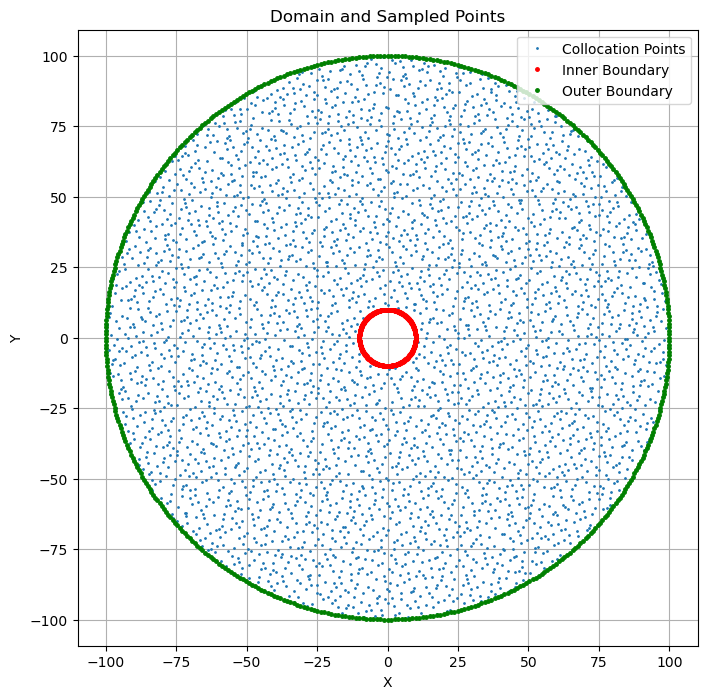

/home/lucas/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 5000/100000, Loss PDE: 0.998098, Loss BC: 0.000137, Loss Norm: 0.280982, Total Loss: 3.808257
Loss Weights: PDE=1.000, BC=10.000, Norm=10.000
Epoch 10000/100000, Loss PDE: 0.001125, Loss BC: 0.000102, Loss Norm: 0.001135, Total Loss: 0.012728
Loss Weights: PDE=1.000, BC=10.000, Norm=10.000
Epoch 15000/100000, Loss PDE: 0.000618, Loss BC: 0.000129, Loss Norm: 0.000000, Total Loss: 0.000940
Loss Weights: PDE=1.000, BC=10.000, Norm=10.000
Epoch 20000/100000, Loss PDE: 0.000618, Loss BC: 0.000129, Loss Norm: 0.000000, Total Loss: 0.000940
Loss Weights: PDE=1.000, BC=10.000, Norm=10.000
Epoch 25000/100000, Loss PDE: 0.000618, Loss BC: 0.000129, Loss Norm: 0.000000, Total Loss: 0.000940
Loss Weights: PDE=1.000, BC=10.000, Norm=10.000
Epoch 30000/100000, Loss PDE: 0.000618, Loss BC: 0.000129, Loss Norm: 0.000000, Total Loss: 0.000940
Loss Weights: PDE=1.000, BC=10.000, Norm=10.000
Epoch 35000/100000, Loss PDE: 0.000620, Loss BC: 0.000129, Loss Norm: 0.000005, Total Loss: 0.000995
Loss W

In [8]:
# ==============================================================================
# Parte 5: Loop de Treinamento Principal
# ==============================================================================

start_time = time.time()
# Define o device (GPU ou CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilizando o device: {device}")

# GERA O TIMESTAMP (data YYYY-MM-DD)
timestamp = datetime.now().strftime("%Y-%m-%d")

# Configura o domínio
domain = CircularDomain(r_in=params['a'],
                        r_out=params['r_max'],
                        n_boundary_points=500,
                        n_colloc_points=5000,
                        n_periodic_points=0, # Não usado
                        bc1_val=0,
                        bc2_val=0)
domain.makeDomain()

# PREPARAÇÃO DOS DADOS
colloc_data = torch.from_numpy(domain.colloc).float().to(device)
bc_data = torch.from_numpy(domain.data).float().to(device)

# Desempacota dados de contorno (BC)
x_bc, y_bc, N_bc = bc_data[:, 0:1], bc_data[:, 1:2], bc_data[:, 2:3]

# Configuração de Mini-Batch para a Loss da PDE e Normalização
BATCH_SIZE = 1024 # Tamanho do lote

colloc_dataset = TensorDataset(colloc_data[:, 0:1], colloc_data[:, 1:2], colloc_data[:, 2:3])
# shuffle=True é crucial para o mini-batching
colloc_loader = DataLoader(colloc_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Inicializa o modelo
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # O LR aqui será o max_lr do Cyclic

# MUDANÇA CRÍTICA: Substituído StepLR por CyclicLR para EXPLORAÇÃO
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9) # Refinamento
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, 
                                            base_lr=1e-6, 
                                            max_lr=1e-3, 
                                            step_size_up=2000, # 2000 épocas para subir
                                            mode='triangular',
                                            cycle_momentum=False) # Exploração

# Pesos de perda fixos
weights = {'pde': 1.0, 'bc': 10.0, 'norm': 10.0}

# Histórico de perdas
loss_history = []

# Loop de treinamento
epochs = 100000
for epoch in range(epochs):
    model.train() # Garante que o modelo está em modo de treino
    epoch_total_loss = 0.0
    epoch_pde_loss = 0.0
    
    # Loop interno de mini-batch
    for x_int_batch, y_int_batch, N_int_batch in colloc_loader:
        optimizer.zero_grad()
        
        # 1. Calcula a Loss da PDE (no mini-batch)
        loss_pde = pde_loss(model, x_int_batch, y_int_batch, N_int_batch, params)
        
        # Cálculo da perda total com pesos (apenas PDE no inner loop)
        batch_loss = weights['pde'] * loss_pde
        
        # Backpropagation e otimização
        batch_loss.backward()
        optimizer.step()
        
        epoch_pde_loss += loss_pde.item() * len(x_int_batch)
    
    # FIM DO LOOP DE MINI-BATCH.
    
    # Calcula BC e Norma (Full-Batch, mas sem gradientes desnecessários)
    # O gradiente da BC e da Norma é calculado implicitamente
    # quando o otimizador é chamado após o backward da PDE.
    # Para um cálculo de perda preciso, devemos somar todas as perdas
    # ANTES do backward.
    
    # CORREÇÃO: A lógica de mini-batching deve incluir todas as perdas
    # ou ser calculada de forma diferente.
    
    # Vamos recalcular o loop de treino para uma abordagem mais estável:
    # Calcular todas as perdas em full-batch (se a memória permitir)
    # ou calcular todas as perdas em mini-batch.
    
    # Tentativa de Otimização: Calcular BC e Norm fora do loop de mini-batch
    # mas adicionar ao gradiente.
    
    optimizer.zero_grad()
    
    # 1. Perda da PDE (Média dos mini-batches)
    avg_pde_loss = epoch_pde_loss / len(colloc_data)
    
    # 2. Perda de BC (Full-Batch)
    loss_bc = bc_loss(model, x_bc, y_bc, N_bc)
    
    # 3. Perda de Normalização (Full-Batch)
    area_factor = (params['r_max']**2 - params['a']**2) * np.pi
    # Usamos os dados de colocation inteiros para a normalização
    loss_norm = normalization_loss(model, colloc_data[:, 0:1], colloc_data[:, 1:2], colloc_data[:, 2:3], area_factor)

    # Calcula a perda total com pesos
    # Nota: A perda PDE já foi otimizada nos mini-batches.
    # Esta é uma abordagem híbrida. O 'total_loss' é para logging.
    # Precisamos recalcular a pde_loss no full-batch para o backward correto
    
    # ==================================
    # REFAZENDO O LOOP DE TREINO (MAIS CORRETO)
    # ==================================
    
    epoch_total_loss_acc = 0.0
    epoch_pde_loss_acc = 0.0
    epoch_bc_loss_acc = 0.0
    epoch_norm_loss_acc = 0.0
    
    # Embaralha os dados de BC também
    bc_dataset = TensorDataset(bc_data[:, 0:1], bc_data[:, 1:2], bc_data[:, 2:3])
    bc_loader = DataLoader(bc_dataset, batch_size=BATCH_SIZE, shuffle=True)
    bc_iter = iter(bc_loader)

    for x_int_batch, y_int_batch, N_int_batch in colloc_loader:
        # Pega um lote de BC
        try:
            x_bc_batch, y_bc_batch, N_bc_batch = next(bc_iter)
        except StopIteration:
            bc_iter = iter(bc_loader) # Reinicia o iterador de BC
            x_bc_batch, y_bc_batch, N_bc_batch = next(bc_iter)
        
        optimizer.zero_grad()
        
        # 1. Loss PDE (Mini-batch)
        loss_pde = pde_loss(model, x_int_batch, y_int_batch, N_int_batch, params)
        
        # 2. Loss BC (Mini-batch)
        loss_bc = bc_loss(model, x_bc_batch, y_bc_batch, N_bc_batch)
        
        # 3. Loss Norma (Aproximada no Mini-batch de Colocation)
        area_factor = (params['r_max']**2 - params['a']**2) * np.pi
        loss_norm = normalization_loss(model, x_int_batch, y_int_batch, N_int_batch, area_factor)

        # 4. Perda Total do Lote
        total_loss_batch = weights['pde'] * loss_pde + \
                           weights['bc'] * loss_bc + \
                           weights['norm'] * loss_norm
        
        # Backward e Otimização
        total_loss_batch.backward()
        optimizer.step()
        
        # Acumula perdas para logging
        epoch_pde_loss_acc += loss_pde.item() * len(x_int_batch)
        epoch_bc_loss_acc += loss_bc.item() * len(x_bc_batch)
        epoch_norm_loss_acc += loss_norm.item() * len(x_int_batch)
        epoch_total_loss_acc += total_loss_batch.item() * len(x_int_batch) # Aproximação

    scheduler.step()
    
    # Média das perdas da época
    avg_total_loss = epoch_total_loss_acc / len(colloc_data)
    avg_pde_loss = epoch_pde_loss_acc / len(colloc_data)
    avg_bc_loss = epoch_bc_loss_acc / len(bc_data)
    avg_norm_loss = epoch_norm_loss_acc / len(colloc_data)
    
    loss_history.append(avg_total_loss)

    if (epoch + 1) % 5000 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss PDE: {avg_pde_loss:.6f}, Loss BC: {avg_bc_loss:.6f}, Loss Norm: {avg_norm_loss:.6f}, Total Loss: {avg_total_loss:.6f}')
        print(f'Loss Weights: PDE={weights["pde"]:.3f}, BC={weights["bc"]:.3f}, Norm={weights["norm"]:.3f}')

end_time = time.time()
print(f"\nTempo de treinamento: {end_time - start_time:.3f}s\n")
print("Treinamento concluído!")

Gerando visualizações dos resultados...
Iniciando geração de frames para o vídeo...
Geração de 25 frames concluída.


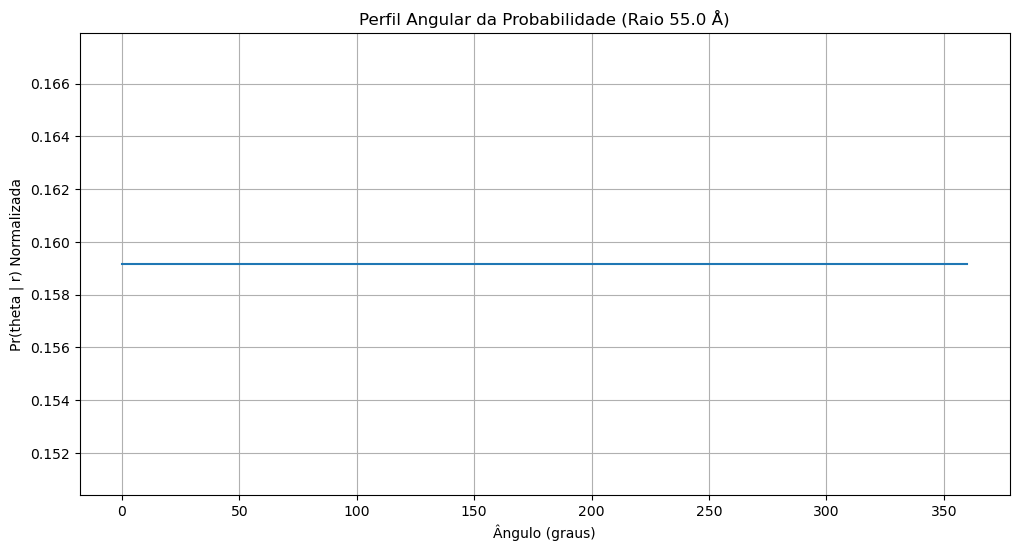

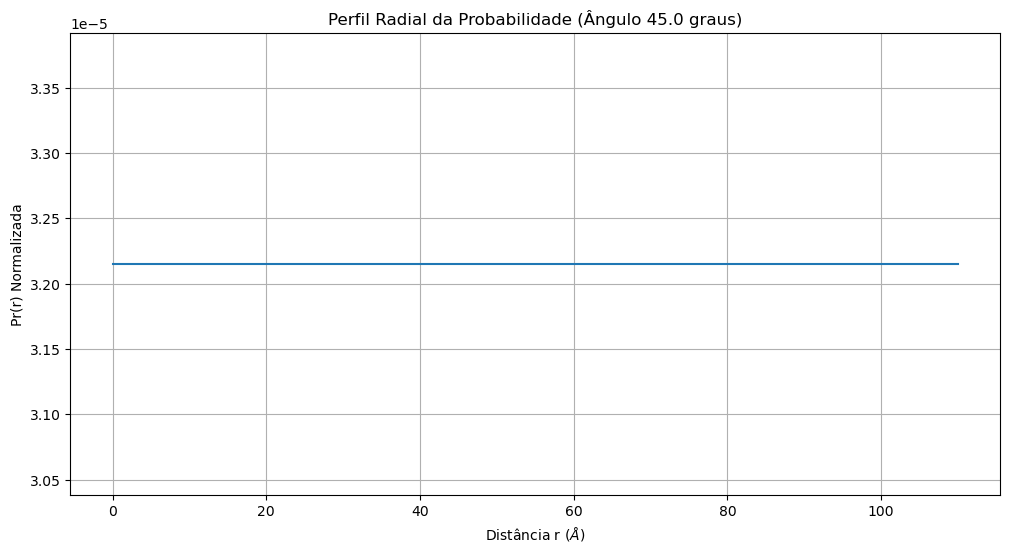

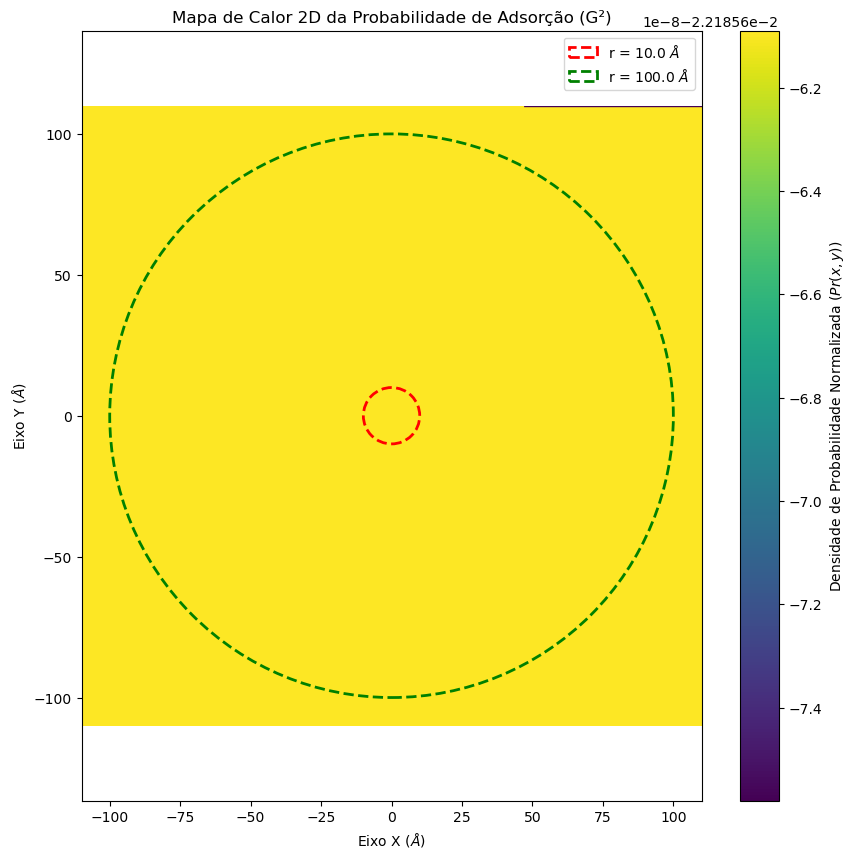

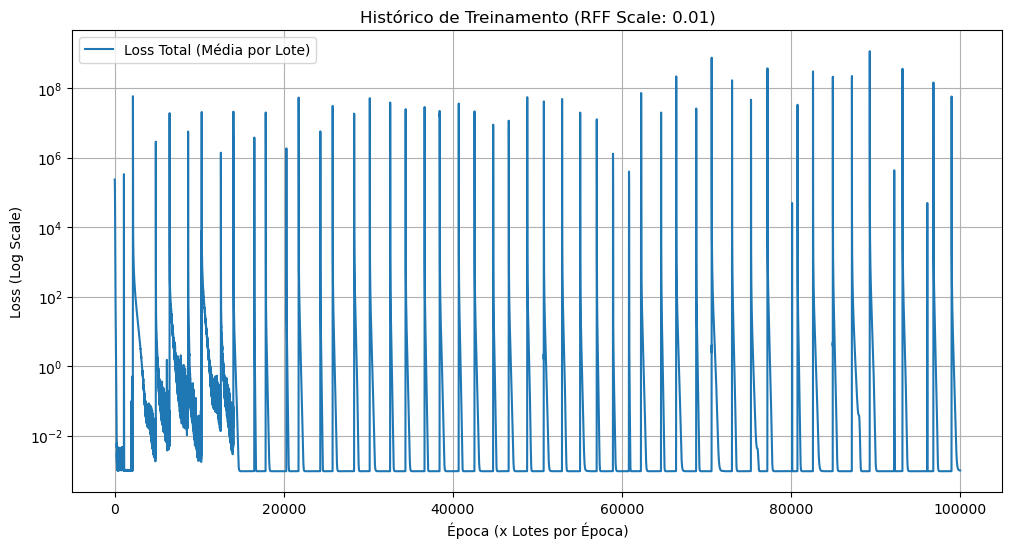

Execução concluída.


In [20]:
# Extrai a escala RFF do modelo para salvar nos arquivos
rff_scale = model.rff_scale

# --- Visualização dos Resultados ---
print("Gerando visualizações dos resultados...")

# Gera os frames para o vídeo (N=1 a N=100)
generate_adsorption_video_frames(model, domain, device, rff_scale, timestamp)

# Plota o perfil angular (N=100)
plot_circular_profile(model, domain, device, rff_scale, timestamp)

# Plota o perfil radial (N=100)
plot_radial_profile(model, domain, device, rff_scale, timestamp)

# Plota o mapa de calor 2D (N=100)
plot_grid_2d(model, domain, device, rff_scale, timestamp)

# Plota o histórico de perda
plot_loss_history(loss_history, rff_scale, timestamp)

print("Execução concluída.")